# Head-Count Sweep: How Many Steered Heads Is Best?

All prior causal-steering runs used a fixed `TOP_K_HEADS = 15`. This notebook sweeps
the number of steered heads (drawn from the same discovery-time ranking) across
**[5, 15, 30, 50, 80, 150, 200]** for all three Qwen2-VL training stages
(base/instruct/agentic), using the `find` phrasing and the corrected no-cue baseline
prompt (steering condition; location-cue is language-only and doesn't depend on head
count, so it's included once for reference, not swept).

**Key efficiency point**: attention-score discovery (the head *ranking*) doesn't
depend on how many heads get steered — only the STEERING step re-selects a
different-sized top-K slice of the same ranking. So discovery runs once per model,
and only the steering+MCQ evaluation is repeated per head count.

In [1]:
%matplotlib inline
import gc
import re
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "vis_head").exists():
    raise RuntimeError("Run this notebook from the repository root (vis-head/).")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import stats
from tqdm.auto import tqdm

from vis_head.common import DEFAULT_SEED
from vis_head.vir import aggregate_region_attention, collect_last_query_attentions, rank_heads_by_score
from vis_head.imagenet_grid import DEFAULT_IMAGENET_ROOT, PROMPT_TEMPLATES, mcq_prompt, list_val_class_dirs, load_class_names, sample_grid
from vis_head.modeling import decode_generated_text, find_image_token_range, load_model_and_processor, model_dims, run_generation
from vis_head.regions import assign_grid_cells_to_tokens, region_positions_from_ids
from vis_head.steering import group_heads_by_layer, intervention_positions, make_static_attention_mask_hook, register_mask_hooks, remove_handles

MODELS = {
    "base": "Qwen/Qwen2-VL-7B",
    "instruct": "Qwen/Qwen2-VL-7B-Instruct",
    "agentic": "ByteDance-Seed/UI-TARS-7B-DPO",
}
DEVICE = "cuda:0"
SEED = DEFAULT_SEED
ROWS, COLS = 2, 2
N_CELLS = ROWS * COLS
CELL_SIZE = 256
N_DISCOVERY_SAMPLES = 300
N_MCQ_SAMPLES = 300
N_OPTIONS = 4
CAUSAL_MAX_NEW_TOKENS = 6
OPTION_LETTERS = ["A", "B", "C", "D"][:N_OPTIONS]
HEAD_COUNTS = [5, 15, 30, 50, 80, 150, 200]

imagenet_class_dirs = list_val_class_dirs(DEFAULT_IMAGENET_ROOT)
imagenet_class_names = load_class_names(DEFAULT_IMAGENET_ROOT)

# base checkpoint has no usable chat template of its own -- render text via the
# instruct processor, feed to all three models (same fix as top2_phrasings notebook).
from transformers import AutoProcessor
_template_processor = AutoProcessor.from_pretrained(MODELS["instruct"])


def render_chat_text(prompt: str) -> str:
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}]
    rendered = _template_processor.apply_chat_template([messages], tokenize=False, add_generation_prompt=True)
    return rendered[0] if isinstance(rendered, list) else rendered


def prepare_inputs_any(processor, image, prompt, device):
    text = render_chat_text(prompt)
    inputs = processor(text=[text], images=[image], return_tensors="pt")
    return inputs.to(device)


print(f"Models: {list(MODELS.keys())}  |  head counts: {HEAD_COUNTS}")

Models: ['base', 'instruct', 'agentic']  |  head counts: [5, 15, 30, 50, 80, 150, 200]


In [2]:
def build_mcq_sample(rng):
    grid = sample_grid(rows=ROWS, cols=COLS, cell_size=CELL_SIZE, rng=rng,
                        class_dirs=imagenet_class_dirs, class_names=imagenet_class_names)
    target_cell = int(rng.randint(N_CELLS))
    correct_name = grid.cell_names[target_cell]
    other_names = [n for i, n in enumerate(grid.cell_names) if i != target_cell]
    n_distractors = min(N_OPTIONS - 1, len(other_names))
    distractor_idx = rng.choice(len(other_names), size=n_distractors, replace=False)
    distractors = [other_names[i] for i in distractor_idx]
    options = [correct_name] + distractors
    order = rng.permutation(len(options))
    options = [options[i] for i in order]
    correct_letter = OPTION_LETTERS[int(np.where(order == 0)[0][0])]
    option_lines = "  ".join(f"{l}) {n}" for l, n in zip(OPTION_LETTERS[:len(options)], options))
    prompt = f"Which of the following is shown in this image? {option_lines}. Answer with only the letter."
    location_prompt = mcq_prompt(target_cell + 1, ROWS, COLS, options, OPTION_LETTERS[:len(options)])
    return {"grid": grid, "target_cell": target_cell, "options": options, "correct_letter": correct_letter,
            "prompt": prompt, "location_prompt": location_prompt}


def extract_letter(text, valid_letters):
    match = re.search(r"\b([" + "".join(valid_letters) + r"])\b", text.upper())
    return match.group(1) if match else None


def run_mcq(model, processor, n_heads, spatial_merge, sample, heads_by_layer, prompt_key="prompt"):
    inputs = prepare_inputs_any(processor, sample["grid"].grid, sample[prompt_key], DEVICE)
    prompt_length = int(inputs["input_ids"].shape[1])
    handles = []
    if heads_by_layer is not None:
        img_start, img_end = find_image_token_range(inputs, processor)
        region_ids, _ = assign_grid_cells_to_tokens(
            image_grid_thw=inputs["image_grid_thw"], rows=ROWS, cols=COLS, spatial_merge=spatial_merge)
        positions = region_positions_from_ids(img_start=img_start, region_ids=region_ids, n_regions=N_CELLS)
        target_positions = positions[sample["target_cell"]]
        other_positions = [p for i in range(N_CELLS) if i != sample["target_cell"] for p in positions[i]]
        suppress_positions, boost_positions, pad = intervention_positions(
            mode="boost_suppress", target_positions=target_positions, other_image_positions=other_positions,
            img_start=img_start, img_end=img_end, prompt_length=prompt_length)
        hook_by_layer = {
            layer_idx: make_static_attention_mask_hook(
                head_indices=heads, suppress_positions=suppress_positions, boost_positions=boost_positions,
                n_query_heads=n_heads, device=DEVICE, decode_only=False, pad_with_suppress=pad)
            for layer_idx, heads in heads_by_layer.items()
        }
        handles = register_mask_hooks(model, hook_by_layer)
    try:
        sequences = run_generation(model=model, inputs=inputs, max_new_tokens=CAUSAL_MAX_NEW_TOKENS)
    finally:
        remove_handles(handles)
    text = decode_generated_text(processor, sequences, prompt_length)
    valid_letters = OPTION_LETTERS[: len(sample["options"])]
    predicted = extract_letter(text, valid_letters)
    return {"text": text, "predicted": predicted, "correct": predicted == sample["correct_letter"]}


def discover_vis_head_scores(model, processor, n_layers, n_heads, spatial_merge, prompt_fn, label, seed):
    rng = np.random.RandomState(seed)
    raw_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    valid = 0
    for _ in tqdm(range(N_DISCOVERY_SAMPLES), desc=f"[{label}] discovery", leave=False):
        grid = sample_grid(rows=ROWS, cols=COLS, cell_size=CELL_SIZE, rng=rng,
                            class_dirs=imagenet_class_dirs, class_names=imagenet_class_names)
        target_cell = int(rng.randint(N_CELLS))
        prompt = prompt_fn(grid.cell_names[target_cell])
        try:
            inputs = prepare_inputs_any(processor, grid.grid, prompt, DEVICE)
            region_ids, _ = assign_grid_cells_to_tokens(
                image_grid_thw=inputs["image_grid_thw"], rows=ROWS, cols=COLS, spatial_merge=spatial_merge)
            attn_at_query = collect_last_query_attentions(model, inputs)
            region_attention = aggregate_region_attention(
                attn_at_query=attn_at_query, inputs=inputs, processor=processor, region_ids=region_ids, n_regions=N_CELLS)
            raw_sum += region_attention[:, :, target_cell]
            valid += 1
        except Exception as exc:
            print(f"Skipping grid: {exc}")
    print(f"  [{label:>10s}] valid={valid}/{N_DISCOVERY_SAMPLES}")
    return (raw_sum / max(valid, 1)).astype(np.float32)

## Run: one discovery pass per model, then sweep head count for steering

In [3]:
results = {}   # model_tag -> {"baseline":.., "location_cue":.., "by_headcount": {k: [...]}}
for model_tag, model_id in MODELS.items():
    print(f"\n=== Loading {model_id} ({model_tag}) ===")
    model, processor = load_model_and_processor(model_id=model_id, device=DEVICE)
    n_layers, n_heads, spatial_merge = model_dims(model)
    print(f"{n_layers} layers x {n_heads} heads (max possible steered heads = {n_layers * n_heads})")

    prompt_fn = lambda name: PROMPT_TEMPLATES["find"].format(name=name)
    vis_head_scores = discover_vis_head_scores(model, processor, n_layers, n_heads, spatial_merge, prompt_fn, model_tag, seed=SEED + 100)
    ranked = rank_heads_by_score(vis_head_scores)

    mcq_rng = np.random.RandomState(SEED + 555)
    mcq_samples = [build_mcq_sample(mcq_rng) for _ in range(N_MCQ_SAMPLES)]

    baseline_res, location_res = [], []
    for sample in tqdm(mcq_samples, desc=f"[{model_tag}] baseline+location", leave=False):
        baseline_res.append(run_mcq(model, processor, n_heads, spatial_merge, sample, None, "prompt"))
        location_res.append(run_mcq(model, processor, n_heads, spatial_merge, sample, None, "location_prompt"))
    b_acc = np.mean([r["correct"] for r in baseline_res])
    l_acc = np.mean([r["correct"] for r in location_res])
    print(f"  [{model_tag}] baseline={b_acc:.3f}  location-cue={l_acc:.3f}")

    by_headcount = {}
    for k in HEAD_COUNTS:
        heads_by_layer = group_heads_by_layer([(r["layer"], r["head"]) for r in ranked[:k]])
        steered_res = []
        for sample in tqdm(mcq_samples, desc=f"[{model_tag}] steered k={k}", leave=False):
            steered_res.append(run_mcq(model, processor, n_heads, spatial_merge, sample, heads_by_layer, "prompt"))
        s_acc = np.mean([r["correct"] for r in steered_res])
        print(f"  [{model_tag}] k={k:>4d}  steered={s_acc:.3f}")
        by_headcount[k] = steered_res

    results[model_tag] = {"baseline": baseline_res, "location_cue": location_res, "by_headcount": by_headcount,
                           "vis_head_scores": vis_head_scores, "n_layers": n_layers, "n_heads": n_heads}

    del model, processor
    gc.collect()
    torch.cuda.empty_cache()


=== Loading Qwen/Qwen2-VL-7B (base) ===


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

28 layers x 28 heads (max possible steered heads = 784)


...

  [agentic] k=  80  steered=0.150


[agentic] steered k=150:   0%|          | 0/300 [00:00<?, ?it/s]

  [agentic] k= 150  steered=0.263


[agentic] steered k=200:   0%|          | 0/300 [00:00<?, ?it/s]

  [agentic] k= 200  steered=0.260


## Results table + plot

   model  head_count  pct_of_total_heads  baseline_acc  location_cue_acc  steered_acc  p_steer_vs_base
    base           5              0.6378        0.1767            0.0667       0.2167           0.0518
    base          15              1.9133        0.1767            0.0667       0.2167           0.0592
    base          30              3.8265        0.1767            0.0667       0.2300           0.0237
    base          50              6.3776        0.1767            0.0667       0.1667           0.7979
    base          80             10.2041        0.1767            0.0667       0.2033           0.3408
    base         150             19.1327        0.1767            0.0667       0.1867           0.8339
    base         200             25.5102        0.1767            0.0667       0.1000           0.0030
instruct           5              0.6378        0.2367            0.9500       0.2967           0.0072
instruct          15              1.9133        0.2367            0.9500 

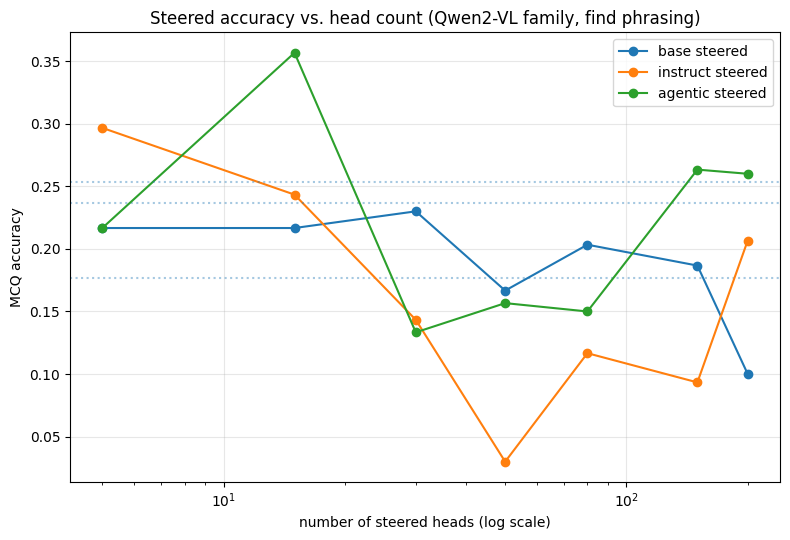

In [4]:
def mcnemar_p(cond_a, cond_b):
    b = sum(1 for a, c in zip(cond_a, cond_b) if not a["correct"] and c["correct"])
    c = sum(1 for a, c in zip(cond_a, cond_b) if a["correct"] and not c["correct"])
    n_discordant = b + c
    if n_discordant == 0:
        return float("nan")
    stat = (abs(b - c) - 1) ** 2 / n_discordant
    return float(stats.chi2.sf(stat, df=1))


rows_summary = []
for model_tag, r in results.items():
    b_acc = np.mean([x["correct"] for x in r["baseline"]])
    l_acc = np.mean([x["correct"] for x in r["location_cue"]])
    for k, steered_res in r["by_headcount"].items():
        s_acc = np.mean([x["correct"] for x in steered_res])
        p_sb = mcnemar_p(r["baseline"], steered_res)
        rows_summary.append({"model": model_tag, "head_count": k, "pct_of_total_heads": 100 * k / (r["n_layers"] * r["n_heads"]),
                              "baseline_acc": b_acc, "location_cue_acc": l_acc, "steered_acc": s_acc, "p_steer_vs_base": p_sb})

df = pd.DataFrame(rows_summary)
pd.set_option("display.width", 140)
print(df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5.5))
for model_tag in MODELS:
    sub = df[df["model"] == model_tag]
    ax.plot(sub["head_count"], sub["steered_acc"], marker="o", label=f"{model_tag} steered")
    ax.axhline(sub["baseline_acc"].iloc[0], linestyle=":", alpha=0.4)
ax.set_xscale("log")
ax.set_xlabel("number of steered heads (log scale)")
ax.set_ylabel("MCQ accuracy")
ax.set_title("Steered accuracy vs. head count (Qwen2-VL family, find phrasing)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/head_count_sweep_qwen2vl.png", dpi=150)
plt.show()

## Result

(filled in after running)